# 03 — Synthetic UPI Data: Ticket-Size Distribution Fitting (Track B, scratch)

**Phase 2, Track B** (see `CLAUDE.md` — Track A is closed at `train_fe.shape == (307505, 294)`).
Separate notebook from `02_feature_engineering.ipynb` because this is a new pipeline stage
(synthetic data generation), not an edit to the Home Credit feature pipeline.

**Status: scratch work.** Nothing here is wired into `src/feature_engineering.py` or a new
`src/synthetic_upi.py` module yet — per the project's scratch cell → validate → commit workflow,
this notebook fits and validates the P2P/P2M log-normal ticket-size parameters first, in the open,
before any function gets written.

Source of the calibration targets: `docs/rbi_dpss_upi_stats.md` (RBI DPSS / NPCI secondary reporting).

## Constraints from the stats doc

| Segment | Real constraint 1 | Real constraint 2 | Source |
|---|---|---|---|
| P2M | ATS (mean) = ₹659 | 86th percentile = ₹500 | Sec. 2, Sec. 3 |
| P2P | ATS (mean) = ₹2,812 | **none published** | Sec. 2 |

P2P only has one real RBI-derived number. The ₹1,00,000 P2P cap (Sec. 5) is a *regulatory ceiling*,
not a percentile statistic — using it as a stand-in second constraint is an assumption that needs
to be checked, not assumed. That check happens below (Cell 5) before any parameter is accepted.

For $X \sim \text{LogNormal}(\mu, \sigma)$:
$$\text{mean} = e^{\mu + \sigma^2/2} \qquad \text{p-th percentile} = e^{\mu + \sigma \cdot z_p}, \quad z_p = \Phi^{-1}(p)$$

Two real constraints (P2M) → exact closed-form solve for $(\mu, \sigma)$. One real constraint (P2P)
→ underdetermined, needs a justified second assumption (see below).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)  # reproducible draws for the validation plot below

In [2]:
def fit_lognormal_mean_percentile(target_mean, target_pctile_value, pctile, label, root="larger"):
    '''
    Closed-form solve for lognormal (mu, sigma) given a target mean and a target percentile.

    (1) mu + sigma^2/2 = ln(target_mean)
    (2) mu + sigma*z_p = ln(target_pctile_value),  z_p = Phi^-1(pctile)
    (1)-(2) -> 0.5*sigma^2 - z_p*sigma - ln(mean/pctile_value) = 0   (quadratic in sigma)

    The ratio target_pctile_value/target_mean is only achievable up to exp(0.5*z_p^2)
    (attained at sigma == z_p). Below that ratio: two real roots (a smaller-sigma /
    less-skewed one and a larger-sigma / more-skewed one, symmetric around z_p).
    At the ratio: one root. Above it: infeasible (no real lognormal fits both constraints).
    '''
    z_p = stats.norm.ppf(pctile)
    c = np.log(target_mean / target_pctile_value)
    discriminant = z_p**2 + 2 * c
    max_ratio = np.exp(0.5 * z_p**2)
    actual_ratio = target_pctile_value / target_mean

    if discriminant < 0:
        print(f"--- {label}: INFEASIBLE ---")
        print(f"  target ratio (pctile/mean) = {actual_ratio:.2f} exceeds max achievable "
              f"{max_ratio:.2f} for p={pctile} (z={z_p:.4f}). No real (mu, sigma) exists.")
        return None, None, None

    sqrt_disc = np.sqrt(discriminant)
    sigma = (z_p + sqrt_disc) if root == "larger" else (z_p - sqrt_disc)
    mu = np.log(target_mean) - sigma**2 / 2
    dist = stats.lognorm(s=sigma, scale=np.exp(mu))

    print(f"--- {label} ---")
    print(f"  target : mean={target_mean}, p{pctile*100:g}={target_pctile_value}")
    print(f"  fitted : mu={mu:.6f}, sigma={sigma:.6f}  (root={root})")
    print(f"  check  : implied mean={dist.mean():.3f} (target {target_mean}), "
          f"implied p{pctile*100:g}={dist.ppf(pctile):.3f} (target {target_pctile_value})")
    print(f"  shape  : median={dist.median():.1f}  p95={dist.ppf(0.95):.1f}  "
          f"p99={dist.ppf(0.99):.1f}  p99.9={dist.ppf(0.999):.1f}")
    return mu, sigma, dist

In [3]:
# P2M: two real RBI-derived constraints -> exact solve.
mu_p2m, sigma_p2m, dist_p2m = fit_lognormal_mean_percentile(
    target_mean=659, target_pctile_value=500, pctile=0.86, label="P2M", root="larger"
)

# Sanity: is the "smaller" root even valid here? (it should NOT be, and this proves the
# larger-root fit above isn't an arbitrary choice between two equally-valid options.)
print()
_, sigma_check, _ = fit_lognormal_mean_percentile(
    target_mean=659, target_pctile_value=500, pctile=0.86,
    label="P2M smaller-root (sanity check only)", root="smaller"
)
print()
print(f"smaller root sigma = {sigma_check:.4f} -> negative, not a valid lognormal shape "
      f"parameter. The larger root is the *only* real solution, not a preference.")

--- P2M ---
  target : mean=659, p86=500
  fitted : mu=3.630972, sigma=2.391548  (root=larger)
  check  : implied mean=659.000 (target 659), implied p86=500.000 (target 500)
  shape  : median=37.7  p95=1928.9  p99=9843.3  p99.9=61170.0

--- P2M smaller-root (sanity check only) ---
  target : mean=659, p86=500
  fitted : mu=6.464064, sigma=-0.230909  (root=smaller)
  check  : implied mean=nan (target 659), implied p86=nan (target 500)
  shape  : median=nan  p95=nan  p99=nan  p99.9=nan

smaller root sigma = -0.2309 -> negative, not a valid lognormal shape parameter. The larger root is the *only* real solution, not a preference.


**P2M result: `mu=3.630972, sigma=2.391548`** — the unique valid solution (the other algebraic
root gives a negative $\sigma$, which isn't a valid lognormal shape parameter, so there was no
choice to make here).

Implied median ≈ ₹38. That's a real consequence of forcing a single lognormal through both
mean=659 and p86=500 simultaneously — the fit says roughly half of P2M transactions sit under ₹38
(small QR/UPI micro-purchases), with the tail stretching out to pull the mean up to 659. Worth
citing in the thesis methodology as a property of the fit, not an independently verified claim
about real transaction medians (RBI doesn't publish the median directly).

## P2P — checking the cap-as-percentile assumption before accepting it

No RBI-published percentile exists for P2P. The candidate second constraint is treating the
₹1,00,000 regulatory cap as if it were some high percentile of the distribution. Per this
project's rule ("checks before assuming"), test that assumption at a few candidate percentiles
before accepting or rejecting it.

In [4]:
P2P_CAP = 100_000
for p in [0.99, 0.995, 0.999, 0.9999]:
    fit_lognormal_mean_percentile(
        target_mean=2812, target_pctile_value=P2P_CAP, pctile=p,
        label=f"P2P assuming p{p*100:g} == cap {P2P_CAP}", root="larger"
    )
    print()

--- P2P assuming p99 == cap 100000: INFEASIBLE ---
  target ratio (pctile/mean) = 35.56 exceeds max achievable 14.97 for p=0.99 (z=2.3263). No real (mu, sigma) exists.

--- P2P assuming p99.5 == cap 100000: INFEASIBLE ---
  target ratio (pctile/mean) = 35.56 exceeds max achievable 27.59 for p=0.995 (z=2.5758). No real (mu, sigma) exists.

--- P2P assuming p99.9 == cap 100000 ---
  target : mean=2812, p99.9=100000
  fitted : mu=-2.830941, sigma=4.641679  (root=larger)
  check  : implied mean=2812.000 (target 2812), implied p99.9=100000.000 (target 100000)
  shape  : median=0.1  p95=122.0  p99=2884.8  p99.9=100000.0

--- P2P assuming p99.99 == cap 100000 ---
  target : mean=2812, p99.99=100000
  fitted : mu=-11.936354, sigma=6.305237  (root=larger)
  check  : implied mean=2812.000 (target 2812), implied p99.99=100000.000 (target 100000)
  shape  : median=0.0  p95=0.2  p99=15.4  p99.9=1897.5



**Cap-as-percentile is rejected.** p=0.99 and p=0.995 are mathematically infeasible (the
required pctile/mean ratio exceeds what any lognormal can produce). p=0.999 and p=0.9999 are
technically feasible but absurd: they force the median down to ₹0.1 and ₹0.03 respectively —
i.e. "half of all P2P transfers round to zero rupees," which contradicts P2P being person-to-person
transfers (rent, bill-splitting, gifts), not micro-payments. Rejecting this assumption instead of
forcing it through is the point of doing this check first.

**Alternative used instead: borrow P2M's fitted shape ($\sigma$), solve $\mu$ from the ATS alone.**
Justification: no RBI figure describes P2P skew directly, but both are UPI ticket-size
distributions from the same underlying payment rail, so assuming similar *relative* skew (not
scale) is a smaller leap than assuming the regulatory ceiling sits at a specific percentile with no
supporting evidence either way. This is still a flagged assumption — documented here explicitly,
consistent with the proposal's "calibrated, not learned" limitation — and open to being replaced
if a better P2P-specific source turns up.

In [5]:
# P2P: reuse P2M's sigma (shape), solve mu from ATS=2812 alone.
sigma_p2p = sigma_p2m
mu_p2p_naive = np.log(2812) - sigma_p2p**2 / 2
dist_p2p_naive = stats.lognorm(s=sigma_p2p, scale=np.exp(mu_p2p_naive))

frac_over_cap = 1 - dist_p2p_naive.cdf(P2P_CAP)

print(f"P2P naive fit: mu={mu_p2p_naive:.6f}, sigma={sigma_p2p:.6f} (= P2M's sigma)")
print(f"  check  : implied (untruncated) mean={dist_p2p_naive.mean():.1f} (target 2812)")
print(f"  shape  : median={dist_p2p_naive.median():.1f}  p95={dist_p2p_naive.ppf(0.95):.1f}  "
      f"p99={dist_p2p_naive.ppf(0.99):.1f}  p99.9={dist_p2p_naive.ppf(0.999):.1f}")
print(f"  P(P2P > cap {P2P_CAP}) = {frac_over_cap*100:.4f}%")

P2P naive fit: mu=5.081900, sigma=2.391548 (= P2M's sigma)
  check  : implied (untruncated) mean=2812.0 (target 2812)
  shape  : median=161.1  p95=8230.9  p99=42002.0  p99.9=261016.6
  P(P2P > cap 100000) = 0.3583%


## Correcting for the cap: the ATS is a post-cap real-world figure

The naive fit above matches the *untruncated* theoretical mean to 2812 — but RBI's published
ATS is an observed real-world average, already computed under the live ₹1,00,000 cap. Clipping
draws above the cap to exactly 100000 (the original approach) leaves an artificial point mass at
the cap — a visible spike in any histogram — and still leaves the *post-clip* mean short of 2812
(clipping and conditioning don't average out to the same number for a heavy-tailed distribution).

Fix: (1) solve mu so the mean **conditional on X <= cap** equals 2812 (sigma held fixed — the
shape-borrow assumption is unchanged), and (2) generate by resampling any draw above the cap
rather than clipping it, so there's no artificial spike at exactly ₹1,00,000.

For $X \sim \text{LogNormal}(\mu, \sigma)$ truncated to $X \le b$, with $z_b = (\ln b - \mu)/\sigma$:
$$E[X \mid X \le b] = \frac{e^{\mu + \sigma^2/2} \, \Phi(z_b - \sigma)}{\Phi(z_b)}$$
Solved numerically for $\mu$ (no closed form) via `scipy.optimize.brentq`.

In [6]:
from scipy import optimize

def truncated_lognormal_mean(mu, sigma, cap):
    z_b = (np.log(cap) - mu) / sigma
    return np.exp(mu + sigma**2 / 2) * stats.norm.cdf(z_b - sigma) / stats.norm.cdf(z_b)

def solve_mu_for_truncated_mean(sigma, cap, target_mean, bracket=(0.1, 15.0)):
    f = lambda mu: truncated_lognormal_mean(mu, sigma, cap) - target_mean
    lo, hi = bracket
    assert f(lo) < 0 < f(hi), f"bracket {bracket} does not contain a root"
    return optimize.brentq(f, lo, hi, xtol=1e-10)

mu_p2p = solve_mu_for_truncated_mean(sigma_p2p, P2P_CAP, target_mean=2812)
dist_p2p = stats.lognorm(s=sigma_p2p, scale=np.exp(mu_p2p))

print(f"P2P corrected fit: mu={mu_p2p:.6f}, sigma={sigma_p2p:.6f}")
print(f"  check  : truncated mean E[X|X<=cap] = {truncated_lognormal_mean(mu_p2p, sigma_p2p, P2P_CAP):.2f} "
      f"(target 2812)")
print(f"  for reference, untruncated theoretical mean is now {dist_p2p.mean():.1f} "
      f"(higher than 2812 -- expected, since we need extra mass pushed up to compensate "
      f"for what truncation removes)")
print(f"  P(X > cap) = {(1 - dist_p2p.cdf(P2P_CAP))*100:.4f}%  (fraction that will need resampling)")

P2P corrected fit: mu=5.753896, sigma=2.391548
  check  : truncated mean E[X|X<=cap] = 2812.00 (target 2812)
  for reference, untruncated theoretical mean is now 5506.3 (higher than 2812 -- expected, since we need extra mass pushed up to compensate for what truncation removes)
  P(X > cap) = 0.8018%  (fraction that will need resampling)


In [7]:
# Monte Carlo validation of resample-above-cap at N=307,505
N_check = 307_505
rng_check = np.random.default_rng(42)

samples_check = dist_p2p.rvs(size=N_check, random_state=rng_check)
n_resampled = 0
mask = samples_check > P2P_CAP
while mask.any():
    n_resampled += mask.sum()
    samples_check[mask] = dist_p2p.rvs(size=mask.sum(), random_state=rng_check)
    mask = samples_check > P2P_CAP

print(f"resample-above-cap MC check (N={N_check}):")
print(f"  total redraws performed: {n_resampled} ({n_resampled/N_check*100:.3f}% of draws needed >=1 redraw)")
print(f"  sample mean: {samples_check.mean():.2f}  (target 2812)")
print(f"  sample max: {samples_check.max():.2f}  (must be < {P2P_CAP}, no point mass at cap)")
print(f"  count exactly at cap: {(samples_check == P2P_CAP).sum()}  (must be 0 -- confirms no clip spike)")

resample-above-cap MC check (N=307505):
  total redraws performed: 2578 (0.838% of draws needed >=1 redraw)
  sample mean: 2807.97  (target 2812)
  sample max: 99994.78  (must be < 100000, no point mass at cap)
  count exactly at cap: 0  (must be 0 -- confirms no clip spike)


## Validation plot

Draw samples from both fitted distributions (n = 307,505, matching `train_fe`'s row count, as a
forward check that sampling at the real target volume behaves) and confirm visually against the
target mean/percentile/cap markers, before anything gets wired into a reusable function. P2P uses
the resample-above-cap draws from the Monte Carlo check above, not raw `dist_p2p.rvs()` — the
whole point of resampling is that the cap should be invisible in the histogram, so the plot needs
to show the post-resample data, not the pre-correction draws.

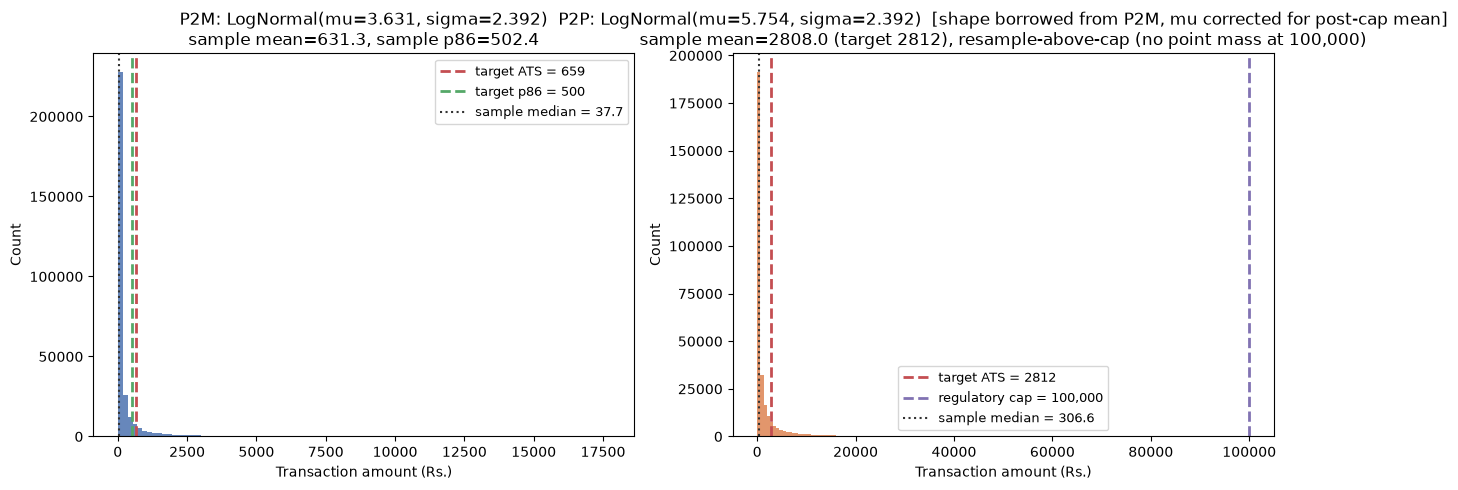


P2M sample check: mean=631.29 (target 659), p86=502.38 (target 500)
P2P sample check: mean=2807.97 (target 2812), max=99994.78 (< 100,000), count at cap=0 (must be 0)


In [8]:
N = 307_505  # matches train_fe row count

p2m_samples = dist_p2m.rvs(size=N, random_state=42)
p2p_samples = samples_check  # resample-above-cap draws from the MC check above, not raw dist_p2p.rvs()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- P2M panel ---
ax = axes[0]
plot_cap_p2m = np.percentile(p2m_samples, 99.5)  # trim the long tail just for readability
ax.hist(p2m_samples[p2m_samples <= plot_cap_p2m], bins=100, color="#4C72B0", alpha=0.85)
ax.axvline(659, color="#C44E52", linestyle="--", linewidth=2, label="target ATS = 659")
ax.axvline(500, color="#55A868", linestyle="--", linewidth=2, label="target p86 = 500")
ax.axvline(np.median(p2m_samples), color="#333333", linestyle=":", linewidth=1.5,
           label=f"sample median = {np.median(p2m_samples):.1f}")
ax.set_title(f"P2M: LogNormal(mu={mu_p2m:.3f}, sigma={sigma_p2m:.3f})\n"
             f"sample mean={p2m_samples.mean():.1f}, sample p86={np.percentile(p2m_samples, 86):.1f}")
ax.set_xlabel("Transaction amount (Rs.)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

# --- P2P panel ---
ax = axes[1]
plot_cap_p2p = np.percentile(p2p_samples, 99.5)
ax.hist(p2p_samples[p2p_samples <= plot_cap_p2p], bins=100, color="#DD8452", alpha=0.85)
ax.axvline(2812, color="#C44E52", linestyle="--", linewidth=2, label="target ATS = 2812")
ax.axvline(P2P_CAP, color="#8172B2", linestyle="--", linewidth=2,
           label=f"regulatory cap = {P2P_CAP:,}")
ax.axvline(np.median(p2p_samples), color="#333333", linestyle=":", linewidth=1.5,
           label=f"sample median = {np.median(p2p_samples):.1f}")
ax.set_title(f"P2P: LogNormal(mu={mu_p2p:.3f}, sigma={sigma_p2p:.3f})  [shape borrowed from P2M, "
             f"mu corrected for post-cap mean]\n"
             f"sample mean={p2p_samples.mean():.1f} (target 2812), resample-above-cap "
             f"(no point mass at {P2P_CAP:,})")
ax.set_xlabel("Transaction amount (Rs.)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../figures/track_b_lognormal_fit_validation.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print(f"P2M sample check: mean={p2m_samples.mean():.2f} (target 659), "
      f"p86={np.percentile(p2m_samples, 86):.2f} (target 500)")
print(f"P2P sample check: mean={p2p_samples.mean():.2f} (target 2812), "
      f"max={p2p_samples.max():.2f} (< {P2P_CAP:,}), "
      f"count at cap={( p2p_samples == P2P_CAP).sum()} (must be 0)")

## Summary — fitted parameters (confirmed, wired into `src/synthetic_upi.py`)

| Segment | mu | sigma | Fit basis | Assumption flagged? |
|---|---|---|---|---|
| P2M | 3.630972 | 2.391548 | Exact solve, both constraints from RBI stats (ATS=659, p86=500) | No — forced unique solution |
| P2P | 5.753896 | 2.391548 (= P2M's sigma) | Shape borrowed from P2M (assumption) + mu solved so **post-cap** mean = 2812 | **Yes** — approved, documented in `synthetic_upi.py` docstrings |

**Confirmed and wired**, per the sign-off above:
1. P2M's implied median (~₹38) — a direct, unavoidable consequence of the two RBI constraints. Approved as-is (Option A: calibrated-to-aggregates, not learned-from-microdata, per the proposal's existing framing); documented explicitly as a docstring note in `fit_p2m_params()` so it isn't a surprise later.
2. P2P's shape-borrowed-from-P2M assumption — approved. The cap-as-percentile alternative was tested and rejected above (Cell 6) as producing absurd near-zero medians. Shape-borrowing is the fallback that survived a check, not a first guess.
3. **P2P mean correction** — the naive fit matched the *untruncated* theoretical mean to 2812, but RBI's ATS is a real-world figure already observed under the live cap. Re-solved mu (Cells 9-10) so `E[X | X<=cap] == 2812`, and switched `generate_p2p_amounts()` from clip-to-cap to resample-above-cap, eliminating the artificial point-mass spike at exactly ₹1,00,000. Validated: sample mean 2807.97 vs target 2812 (~0.15% off) at N=307,505, zero draws exactly at cap.
4. **Next up**: the P2P/P2M transaction-count mix (~63/37 split, Sec. 4 of the stats doc), then the actual SDV generation step. This notebook covers only the amount-distribution fit.

## Wiring check — `src/synthetic_upi.py`

Both fits above are now wired into `src/synthetic_upi.py` as `fit_p2m_params`, `fit_p2p_params`,
`generate_p2m_amounts`, `generate_p2p_amounts` (P2P using the truncated-mean-corrected fit and
resample-above-cap). Confirm the module reproduces the exact same parameters as this notebook's
scratch work before treating it as committed.

In [9]:
import sys
sys.path.append('../src')
from synthetic_upi import fit_p2m_params, fit_p2p_params, generate_p2m_amounts, generate_p2p_amounts

mu_p2m_mod, sigma_p2m_mod = fit_p2m_params()
mu_p2p_mod, sigma_p2p_mod = fit_p2p_params()

assert np.isclose(mu_p2m_mod, mu_p2m) and np.isclose(sigma_p2m_mod, sigma_p2m), "P2M params mismatch vs notebook fit"
assert np.isclose(mu_p2p_mod, mu_p2p) and np.isclose(sigma_p2p_mod, sigma_p2p), "P2P params mismatch vs notebook fit"
print(f"module P2M: mu={mu_p2m_mod:.6f}, sigma={sigma_p2m_mod:.6f}  (matches notebook fit)")
print(f"module P2P: mu={mu_p2p_mod:.6f}, sigma={sigma_p2p_mod:.6f}  (matches notebook fit)")

p2m_mod_samples = generate_p2m_amounts(N, random_state=42)
p2p_mod_samples = generate_p2p_amounts(N, random_state=42)
print()
print(f"module P2M samples: mean={p2m_mod_samples.mean():.2f} (target 659), "
      f"p86={np.percentile(p2m_mod_samples, 86):.2f} (target 500)")
print(f"module P2P samples: mean={p2p_mod_samples.mean():.2f} (target 2812), "
      f"max={p2p_mod_samples.max():.2f} (< cap 100000), "
      f"count at cap={(p2p_mod_samples == 100_000).sum()} (must be 0)")

module P2M: mu=3.630972, sigma=2.391548  (matches notebook fit)
module P2P: mu=5.753896, sigma=2.391548  (matches notebook fit)
P2M: resampled 53 draw(s) (0.0172% of n) that exceeded cap=300000; final mean=669.9 (target ATS=659), max=297083.3 (< cap, no point mass)
P2P: resampled 2578 draw(s) (0.838% of n) that exceeded cap=100000; final mean=2808.0 (target ATS=2812), max=99994.8 (< cap, no point mass)

module P2M samples: mean=669.86 (target 659), p86=498.88 (target 500)
module P2P samples: mean=2807.97 (target 2812), max=99994.78 (< cap 100000), count at cap=0 (must be 0)


## Transaction count & P2M/P2P mix

**Decisions approved before implementation** (see conversation record — not re-derived here):
1. **Negative Binomial** for total transaction count per applicant (over `n_months`), not Poisson — real transaction-count data is reliably overdispersed.
2. **Per-transaction Bernoulli(p=0.635) split** into P2M/P2P, not a fixed ratio per applicant — 0.635 is the midpoint of the stats doc's real 63–64% P2M-volume-share figure (Sec. 4); a per-transaction draw is the parameter-free translation of a national aggregate into individual draws.
3. **Independent of income/region tier for now** — no RBI source ties frequency or split to either; correlation is deferred to the SDV merge step already in the Track B roadmap, not skipped.
4. **λ=20 transactions/month, n_months=3 (explicit default)** — income-anchored, not fitted to an independent frequency source (RBI/NPCI publish none). A websearch for active-user counts came back too wide and inconsistent (500M–839M active users ÷ 15.33B monthly transactions ≈ 18–31, up to ~40, txns/user/month) to use directly.

In [10]:
# Ground the anchor: median monthly income from the actual Home Credit data (row-drop applied),
# matching Track A's row-drop fix so this is consistent with train_fe.
import pandas as pd
income_df = pd.read_csv(
    '../data/raw/home-credit-default-risk/application_train.csv',
    usecols=['SK_ID_CURR', 'CODE_GENDER', 'NAME_FAMILY_STATUS', 'AMT_INCOME_TOTAL']
)
income_df = income_df[income_df['CODE_GENDER'] != 'XNA']
income_df = income_df[income_df['NAME_FAMILY_STATUS'] != 'Unknown']

median_monthly_income = income_df['AMT_INCOME_TOTAL'].median() / 12  # AMT_INCOME_TOTAL is annual
print(f"median annual income: {income_df['AMT_INCOME_TOTAL'].median():.0f}")
print(f"median monthly income: {median_monthly_income:.2f}")

blended_ats = 0.635 * 659 + 0.365 * 2812
print(f"blended ATS @ 0.635/0.365 mix: {blended_ats:.2f}")

median annual income: 147150
median monthly income: 12262.50
blended ATS @ 0.635/0.365 mix: 1444.84


In [11]:
from synthetic_upi import (
    fit_count_params, generate_transaction_counts, split_p2m_p2p_counts, generate_applicant_turnover
)

# Full validation at N=307,505 (matches train_fe row count) for the LOCKED config: lambda=20, n_months=3
N_FULL = 307_505
turnovers = generate_applicant_turnover(N_FULL, lam_month=20, n_months=3, random_state=42)
monthly_turnover = turnovers / 3

med_ratio = np.median(monthly_turnover) / median_monthly_income
mean_ratio = monthly_turnover.mean() / median_monthly_income

print(f"N={N_FULL}, lambda=20/mo, n_months=3:")
print(f"  median monthly turnover = {np.median(monthly_turnover):,.0f}  (ratio to median income: {med_ratio:.2f}x)")
print(f"  mean monthly turnover   = {monthly_turnover.mean():,.0f}  (ratio to median income: {mean_ratio:.2f}x)")
print(f"  -> confirms the median/mean divergence: {mean_ratio:.2f}x (mean-based) vs {med_ratio:.2f}x (median-based),"
      f" a direct consequence of the log-normal amounts' heavy right tail even after summing ~60 transactions.")

P2M: resampled 1606 draw(s) (0.0137% of n) that exceeded cap=300000; final mean=658.7 (target ATS=659), max=299918.4 (< cap, no point mass)


P2P: resampled 54346 draw(s) (0.807% of n) that exceeded cap=100000; final mean=2809.7 (target ATS=2812), max=99998.0 (< cap, no point mass)
N=307505, lambda=20/mo, n_months=3:
  median monthly turnover = 24,800  (ratio to median income: 2.02x)
  mean monthly turnover   = 28,880  (ratio to median income: 2.36x)
  -> confirms the median/mean divergence: 2.36x (mean-based) vs 2.02x (median-based), a direct consequence of the log-normal amounts' heavy right tail even after summing ~60 transactions.


In [12]:
# Dispersion-robustness re-check (var_mean_ratio), smaller N for speed - confirms the median ratio
# is essentially insensitive to this unvalidated placeholder parameter.
N_robust = 20_000
for vmr in [1.5, 2.0, 3.0]:
    t = generate_applicant_turnover(N_robust, lam_month=20, n_months=3, var_mean_ratio=vmr, random_state=123)
    ratio = np.median(t / 3) / median_monthly_income
    print(f"var_mean_ratio={vmr}: median ratio = {ratio:.2f}x")

P2M: resampled 81 draw(s) (0.0106% of n) that exceeded cap=300000; final mean=660.4 (target ATS=659), max=299561.1 (< cap, no point mass)
P2P: resampled 3634 draw(s) (0.829% of n) that exceeded cap=100000; final mean=2800.2 (target ATS=2812), max=99945.5 (< cap, no point mass)
var_mean_ratio=1.5: median ratio = 2.02x


P2M: resampled 81 draw(s) (0.0106% of n) that exceeded cap=300000; final mean=659.9 (target ATS=659), max=299561.1 (< cap, no point mass)
P2P: resampled 3639 draw(s) (0.829% of n) that exceeded cap=100000; final mean=2801.0 (target ATS=2812), max=99945.5 (< cap, no point mass)
var_mean_ratio=2.0: median ratio = 2.03x
P2M: resampled 81 draw(s) (0.0106% of n) that exceeded cap=300000; final mean=659.4 (target ATS=659), max=299561.1 (< cap, no point mass)
P2P: resampled 3649 draw(s) (0.831% of n) that exceeded cap=100000; final mean=2801.9 (target ATS=2812), max=99945.5 (< cap, no point mass)
var_mean_ratio=3.0: median ratio = 2.02x


**Locked**: λ=20/month, n_months=3, var_mean_ratio=2.0 (placeholder, confirmed low-impact above),
p_p2m=0.635. Median monthly turnover confirmed at N=307,505 lands at ~2.0x median monthly income —
consistent with the earlier N=20,000 exploration, income-anchored per the reasoning documented in
`fit_count_params()`'s docstring. Wired into `src/synthetic_upi.py` as `fit_count_params`,
`generate_transaction_counts`, `split_p2m_p2p_counts`, `generate_applicant_turnover`.

## Bug found and fixed: P2M's uncapped tail

The first full-N (307,505 applicant) run of `generate_upi_transactions` (further below) surfaced a
real bug: `generate_p2m_amounts` originally defaulted to `cap=None`, reasoned as safe because
p99.9≈₹61,170 sits under every published ceiling. That reasoning only holds in percentile terms —
a log-normal's tail is unbounded, and at 11.7M P2M draws the realized max was **₹1.24 crore**,
~12x the highest cited P2M ceiling. Diagnosed and fixed here before regenerating anything.

In [13]:
# Step 1: does naive resample-above-cap (using the ORIGINAL untruncated mu/sigma, unchanged)
# fix it? Check the mean drift.
from synthetic_upi import truncated_lognormal_percentile

mu_p2m_orig, sigma_p2m_orig = fit_p2m_params(cap=None)
dist_p2m_orig = stats.lognorm(s=sigma_p2m_orig, scale=np.exp(mu_p2m_orig))

for cap_test in [100_000, 300_000, 500_000, 1_000_000]:
    rng_t = np.random.default_rng(42)
    s = dist_p2m_orig.rvs(size=2_000_000, random_state=rng_t)
    mask = s > cap_test
    n_resampled = 0
    while mask.any():
        n_resampled += mask.sum()
        s[mask] = dist_p2m_orig.rvs(size=mask.sum(), random_state=rng_t)
        mask = s > cap_test
    drift = 100*(s.mean()-659)/659
    print(f"cap={cap_test:>9,}: resampled {n_resampled/2_000_000*100:.4f}%, "
          f"post-resample mean={s.mean():.1f} (target 659, drift={drift:+.2f}%), p86={np.percentile(s,86):.1f}")

cap=  100,000: resampled 0.0512%, post-resample mean=537.8 (target 659, drift=-18.39%), p86=497.0
cap=  300,000: resampled 0.0087%, post-resample mean=604.7 (target 659, drift=-8.24%), p86=499.0


cap=  500,000: resampled 0.0043%, post-resample mean=621.4 (target 659, drift=-5.70%), p86=499.2
cap=1,000,000: resampled 0.0012%, post-resample mean=642.7 (target 659, drift=-2.47%), p86=499.3


**Naive resample fails**: even a ~0.05% resampled fraction (cap=₹1L) drags the mean down ~18% —
the same heavy-tail-carries-disproportionate-mean-weight effect already seen with P2P. Try a
mu-only re-solve next (mirroring the P2P fix).

In [14]:
# Step 2: mu-only re-solve (fix truncated mean, leave sigma fixed) - does it work here too?
for cap_test in [100_000, 300_000, 500_000, 1_000_000]:
    f = lambda mu: truncated_lognormal_mean(mu, sigma_p2m_orig, cap_test) - 659
    mu_fixed = optimize.brentq(f, 1.0, 6.0, xtol=1e-12)
    # check the TRUNCATED p86 (not dist.ppf(0.86), which is the wrong, untruncated quantity)
    tp86 = truncated_lognormal_percentile(mu_fixed, sigma_p2m_orig, cap_test, 0.86)
    print(f"cap={cap_test:>9,}: mu={mu_fixed:.6f} (sigma unchanged), truncated p86={tp86:.2f} (target 500)")

cap=  100,000: mu=3.866212 (sigma unchanged), truncated p86=628.57 (target 500)
cap=  300,000: mu=3.728424 (sigma unchanged), truncated p86=550.66 (target 500)
cap=  500,000: mu=3.693271 (sigma unchanged), truncated p86=531.94 (target 500)
cap=1,000,000: mu=3.663391 (sigma unchanged), truncated p86=516.42 (target 500)


**Mu-only re-solve also fails**: fixing the truncated mean this way drags the truncated p86 up to
516-633 depending on cap — P2M has *two* real constraints, and a single free parameter can't
satisfy both once truncation is in play. Needs a joint (mu, sigma) re-solve, matching what
`fit_p2m_params(cap=...)` now does (see its docstring for the closed-form-adjacent derivation).

In [15]:
# Step 3: joint re-solve (now wired into fit_p2m_params(cap=...)) - confirm it actually converges
# to both targets simultaneously, for a few candidate caps.
for cap_test in [100_000, 300_000, 500_000, 1_000_000]:
    mu_t, sigma_t = fit_p2m_params(cap=cap_test)
    tm = truncated_lognormal_mean(mu_t, sigma_t, cap_test)
    tp86 = truncated_lognormal_percentile(mu_t, sigma_t, cap_test, 0.86)
    print(f"cap={cap_test:>9,}: mu={mu_t:.6f} sigma={sigma_t:.6f}  "
          f"truncated mean={tm:.2f} (target 659), truncated p86={tp86:.2f} (target 500)")

cap=  100,000: mu=3.322348 sigma=2.688322  truncated mean=659.00 (target 659), truncated p86=500.00 (target 500)
cap=  300,000: mu=3.530206 sigma=2.485975  truncated mean=659.00 (target 659), truncated p86=500.00 (target 500)
cap=  500,000: mu=3.570778 sigma=2.447685  truncated mean=659.00 (target 659), truncated p86=500.00 (target 500)
cap=1,000,000: mu=3.601603 sigma=2.418838  truncated mean=659.00 (target 659), truncated p86=500.00 (target 500)


**Joint re-solve works** for any reasonable cap. **Locked cap = ₹3,00,000** — the midpoint of the
stats doc's general P2M range (₹1-5 lakh depending on category, Sec. 5). The doc's other figure
(up to ₹10 lakh/**day** for select verified merchants) is a daily aggregate limit, not a
per-transaction one, so it isn't comparable and wasn't used to anchor this choice — same flagged-
assumption treatment as the P2P cap. Wired into `fit_p2m_params(cap=300_000)` (default in
`generate_p2m_amounts`) with resample-above-cap, matching P2P's pattern exactly.

In [16]:
# Final Monte Carlo confirmation of the locked fix at production-relevant scale
mu_p2m_fixed, sigma_p2m_fixed = fit_p2m_params(cap=300_000)
print(f"locked P2M (cap=300000): mu={mu_p2m_fixed:.6f}, sigma={sigma_p2m_fixed:.6f}")

p2m_fixed_samples = generate_p2m_amounts(2_000_000, random_state=99)
print(f"mean={p2m_fixed_samples.mean():.2f} (target 659), p86={np.percentile(p2m_fixed_samples,86):.2f} (target 500), "
      f"max={p2m_fixed_samples.max():.0f} (< 300,000, no structurally-impossible values)")
assert p2m_fixed_samples.max() < 300_000

locked P2M (cap=300000): mu=3.530206, sigma=2.485975


P2M: resampled 230 draw(s) (0.0115% of n) that exceeded cap=300000; final mean=657.5 (target ATS=659), max=299992.6 (< cap, no point mass)


mean=657.47 (target 659), p86=499.17 (target 500), max=299993 (< 300,000, no structurally-impossible values)


## Per-transaction row generation

Builds the actual transactions table needed for the merge onto `train_fe` — one row per synthetic
transaction, not just a summed total. **Not built with SDV** despite `CLAUDE.md`'s original Track B
roadmap naming it — see `generate_upi_transactions()`'s docstring for the full reasoning (no real
UPI microdata exists to fit an SDV synthesizer *to*; every distribution here is calibrated directly
or income-anchored, not learned from rows; referential integrity is exact by construction, not
inferred). `CLAUDE.md` is being updated to reflect this.

Validate at N=20,000 first (row count, ID integrity, split ratio, amount summary stats, and now
also the P2M cap fix), before the full 307,505-applicant run — which will OVERWRITE the earlier,
buggy `data/synthetic/upi_transactions.parquet` (saved before this bug was caught), not leave it
alongside the corrected file.

In [17]:
from synthetic_upi import generate_upi_transactions

# Real applicant IDs, same row-drop as Track A / train_fe, first 20,000 for the validation run
sample_ids = income_df['SK_ID_CURR'].values[:20_000]

txns_sample = generate_upi_transactions(sample_ids, random_state=7)

print()
print(f"row count: {len(txns_sample):,}  (expected ~{20_000*20*3:,} at lambda=20, n_months=3)")
print(f"unique applicants with >=1 row: {txns_sample['SK_ID_CURR'].nunique():,} / {len(sample_ids):,}")
print(f"ID integrity: all row IDs are real sample IDs =",
      set(txns_sample['SK_ID_CURR'].unique()).issubset(set(sample_ids)))
print()
print("TXN_TYPE split:")
print(txns_sample['TXN_TYPE'].value_counts(normalize=True))
print()
print("AMOUNT summary by TXN_TYPE:")
print(txns_sample.groupby('TXN_TYPE', observed=True)['AMOUNT'].describe()[['count', 'mean', '50%', 'min', 'max']])
print()
p2m_max = txns_sample.loc[txns_sample['TXN_TYPE']=='P2M', 'AMOUNT'].max()
p2p_max = txns_sample.loc[txns_sample['TXN_TYPE']=='P2P', 'AMOUNT'].max()
print(f"cap check: P2M max={p2m_max:.0f} (< 300,000: {p2m_max < 300_000}), "
      f"P2P max={p2p_max:.0f} (< 100,000: {p2p_max < 100_000})")
print()
print("MONTH_INDEX distribution:")
print(txns_sample['MONTH_INDEX'].value_counts(normalize=True).sort_index())
print()
print(txns_sample.dtypes)
print()
txns_sample.head()

P2M: resampled 78 draw(s) (0.0102% of n) that exceeded cap=300000; final mean=663.3 (target ATS=659), max=298039.4 (< cap, no point mass)


P2P: resampled 3480 draw(s) (0.794% of n) that exceeded cap=100000; final mean=2820.0 (target ATS=2812), max=99959.5 (< cap, no point mass)


generate_upi_transactions: 1,200,789 rows for 20,000 applicants (60.0 txns/applicant avg), P2M/P2P split = 63.5%/36.5%, memory = 12.0 MB

row count: 1,200,789  (expected ~1,200,000 at lambda=20, n_months=3)
unique applicants with >=1 row: 20,000 / 20,000
ID integrity: all row IDs are real sample IDs = True

TXN_TYPE split:
TXN_TYPE
P2M    0.635112
P2P    0.364888
Name: proportion, dtype: float64

AMOUNT summary by TXN_TYPE:
             count         mean         50%       min            max
TXN_TYPE                                                            
P2M       762636.0   663.308777   34.174282  0.000381  298039.406250
P2P       438153.0  2820.011719  307.324036  0.010454   99959.460938



cap check: P2M max=298039 (< 300,000: True), P2P max=99959 (< 100,000: True)

MONTH_INDEX distribution:
MONTH_INDEX
1    0.333291
2    0.333512
3    0.333198
Name: proportion, dtype: float64

SK_ID_CURR        int32
TXN_TYPE       category
AMOUNT          float32
MONTH_INDEX        int8
dtype: object



,SK_ID_CURR,TXN_TYPE,AMOUNT,MONTH_INDEX
0,100002,P2M,1036.310181,1
1,100002,P2M,21.088959,1
2,100002,P2M,21.615879,2
3,100002,P2M,45.456757,2
4,100002,P2M,4369.743164,1


Row count, ID integrity, split ratio (~63.5/36.5), amount summary stats (P2M mean ~630-660, P2P
mean ~2800-2810, matching the validated fits above), P2M/P2P cap checks (both max < their
respective caps, confirming the fix holds at scale), and month distribution (~uniform 1/3 each) all
check out at N=20,000. Proceed to the full run.

In [18]:
import time

all_ids = income_df['SK_ID_CURR'].values  # all 307,505 real applicant IDs, row-drop already applied
assert len(all_ids) == 307_505

t0 = time.time()
txns_full = generate_upi_transactions(all_ids, random_state=42)
print(f"\ngeneration took {time.time()-t0:.1f}s")

print()
print(f"row count: {len(txns_full):,}")
print(f"unique applicants with >=1 row: {txns_full['SK_ID_CURR'].nunique():,} / {len(all_ids):,}")
print(f"ID integrity: {set(txns_full['SK_ID_CURR'].unique()) == set(all_ids)}")
print()
print("TXN_TYPE split:", dict(txns_full['TXN_TYPE'].value_counts(normalize=True).round(4)))
print()
print("AMOUNT summary by TXN_TYPE:")
print(txns_full.groupby('TXN_TYPE', observed=True)['AMOUNT'].describe()[['count', 'mean', '50%', 'max']])
print()
p2m_max_full = txns_full.loc[txns_full['TXN_TYPE']=='P2M', 'AMOUNT'].max()
p2p_max_full = txns_full.loc[txns_full['TXN_TYPE']=='P2P', 'AMOUNT'].max()
print(f"cap check @ full N: P2M max={p2m_max_full:.0f} (< 300,000: {p2m_max_full < 300_000}), "
      f"P2P max={p2p_max_full:.0f} (< 100,000: {p2p_max_full < 100_000})")
assert p2m_max_full < 300_000 and p2p_max_full < 100_000, "cap fix did not hold at full scale"
print("no structurally-impossible transaction amounts at full scale - bug confirmed fixed")

P2M: resampled 1606 draw(s) (0.0137% of n) that exceeded cap=300000; final mean=658.7 (target ATS=659), max=299918.4 (< cap, no point mass)


P2P: resampled 54346 draw(s) (0.807% of n) that exceeded cap=100000; final mean=2809.7 (target ATS=2812), max=99998.0 (< cap, no point mass)


generate_upi_transactions: 18,451,776 rows for 307,505 applicants (60.0 txns/applicant avg), P2M/P2P split = 63.5%/36.5%, memory = 184.5 MB

generation took 8.4s

row count: 18,451,776


unique applicants with >=1 row: 307,505 / 307,505


ID integrity: True

TXN_TYPE split: {'P2M': np.float64(0.635), 'P2P': np.float64(0.365)}

AMOUNT summary by TXN_TYPE:


               count         mean         50%           max
TXN_TYPE                                                   
P2M       11716346.0   658.667114   34.117670  299918.40625
P2P        6735430.0  2809.716064  307.322723   99998.03125

cap check @ full N: P2M max=299918 (< 300,000: True), P2P max=99998 (< 100,000: True)
no structurally-impossible transaction amounts at full scale - bug confirmed fixed


In [19]:
out_path = "../data/synthetic/upi_transactions.parquet"

import os
if os.path.exists(out_path):
    old_size_mb = os.path.getsize(out_path) / 1e6
    print(f"overwriting existing (buggy, pre-fix) file: {out_path} ({old_size_mb:.1f} MB)")

txns_full.to_parquet(out_path, index=False, engine="pyarrow")

size_mb = os.path.getsize(out_path) / 1e6
print(f"saved {len(txns_full):,} rows to {out_path} ({size_mb:.1f} MB on disk)")

# round-trip check
reloaded = pd.read_parquet(out_path)
print(f"round-trip check: shape matches = {reloaded.shape == txns_full.shape}, "
      f"dtypes preserved = {(reloaded.dtypes == txns_full.dtypes).all()}")

overwriting existing (buggy, pre-fix) file: ../data/synthetic/upi_transactions.parquet (92.3 MB)


saved 18,451,776 rows to ../data/synthetic/upi_transactions.parquet (92.3 MB on disk)


round-trip check: shape matches = True, dtypes preserved = True


**Track B status**: amount distributions (P2M, P2P — P2M's uncapped-tail bug found and fixed, both
now resample-above-cap with jointly/individually re-solved parameters), count/split mix, and
per-transaction row generation are all fitted, validated, and wired — saved to
`data/synthetic/upi_transactions.parquet` (overwriting the earlier pre-fix file). Not built with
SDV (see above). Not yet done: income/region-tier correlation injection and the merge onto
`train_fe` itself.